In [1]:
import os
import tempfile
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
# If error, downgrade to: numpy 1.26.0

In [2]:
import scvi
from rich import print

/sc/arion/projects/ad-omics/raphael/conda/envs/scvi_cellassign/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
hnoca_adata = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/HNOCA/hnoca_cleanedmeta.h5ad')
zeng_adata = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/Zeng/data/07092025_zeng_humanized.h5ad')
linnarsson_adata = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/Linnarsson/data/07092025_linnarsson_humanized.h5ad')

/sc/arion/projects/ad-omics/raphael/conda/envs/scvi_cellassign/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
hnoca_adata.var_names

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'ENSG00000288716', 'ENSG00000288717', 'ENSG00000288718',
       'ENSG00000288719', 'ENSG00000288720', 'ENSG00000288721', 'F8A1',
       'ENSG00000288723', 'ENSG00000288724', 'ENSG00000288725'],
      dtype='object', length=36842)

In [5]:
zeng_adata.var_names

Index(['XKR4', 'RP1', 'SOX17', 'MRPL15', 'LYPLA1', 'TCEA1', 'RGS20', 'ATP6V1H',
       'OPRK1', 'NPBWR1',
       ...
       'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5',
       'MT-ND6', 'MT-CYB', 'PRAMEF26'],
      dtype='object', length=16452)

In [6]:
linnarsson_adata.var_names

Index(['PTK6', 'AQP8', 'NEIL2', 'LAMC1', 'FXYD3', 'LAMA1', 'HS3ST1', 'FABP3',
       'NRG2', 'KDELR3',
       ...
       'FGF16', 'ZMYM3', 'ARR3', 'FAM3A', 'GPR155', 'SCG5', 'VPS37A', 'PCF11',
       'SYNE4', 'GPATCH1'],
      dtype='object', length=16434)

In [7]:
# Round HNOCA counts (length-normalized)
import numpy as np

hnoca_adata.X = np.round(hnoca_adata.X)

In [8]:
linnarsson_adata.obs['dataset'] = 'La Manno (2021)'
linnarsson_adata.obs['organism'] = 'Mouse'

hnoca_adata.obs['dataset'] = 'He (2024)'
hnoca_adata.obs['organism'] = 'Human'

zeng_adata.obs['dataset'] = 'Jin (2025)'
zeng_adata.obs['organism'] = 'Mouse'

In [9]:
zeng_adata.var_names

Index(['XKR4', 'RP1', 'SOX17', 'MRPL15', 'LYPLA1', 'TCEA1', 'RGS20', 'ATP6V1H',
       'OPRK1', 'NPBWR1',
       ...
       'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5',
       'MT-ND6', 'MT-CYB', 'PRAMEF26'],
      dtype='object', length=16452)

In [10]:
Bhaduri_2021 = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/Bhaduri_2021/Bhaduri_2021.h5ad')
Linnarsson_2023 = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/Linnarsson/data/2023/Linnarsson_2023.h5ad')
Velmeshev_2023 = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/Velmeshev/data/2023/Velmeshev_2023.h5ad')
Zhu_2023 = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/Zhu_2023/Zhu_2023.h5ad')
Wang_2025 = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/Wang_2025/Wang_2025.h5ad')
wang_2022 = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/Wang_2022/wang2022_annotated.h5ad')


In [11]:
Bhaduri_2021.obs['dataset'] = 'Bhaduri (2021)'
Bhaduri_2021.obs['organism'] = 'Human'

Linnarsson_2023.obs['dataset'] = 'Braun (2023)'
Linnarsson_2023.obs['organism'] = 'Human'

Velmeshev_2023.obs['dataset'] = 'Velmeshev (2023)'
Velmeshev_2023.obs['organism'] = 'Human'

Zhu_2023.obs['dataset'] = 'Zhu (2023)'
Zhu_2023.obs['organism'] = 'Human'

Wang_2025.obs['dataset'] = 'Wang (2025)'
Wang_2025.obs['organism'] = 'Human'

wang_2022.obs['dataset'] = 'Wang (2022)'
wang_2022.obs['organism'] = 'Human'

In [12]:
Bhaduri_2021.var_names

Index(['ENSG00000238009', 'ENSG00000228463', 'ENSG00000237094',
       'ENSG00000237491', 'ENSG00000225880', 'ENSG00000230368',
       'ENSG00000272438', 'ENSG00000230699', 'ENSG00000241180',
       'ENSG00000187634',
       ...
       'ENSG00000258064', 'ENSG00000258235', 'ENSG00000198033',
       'ENSG00000260343', 'ENSG00000258912', 'ENSG00000140478',
       'ENSG00000231477', 'ENSG00000263588', 'ENSG00000125815',
       'ENSG00000228587'],
      dtype='object', length=26850)

In [13]:
import pandas as pd
from pathlib import Path

# put your desired directory here
out_dir = Path("/sc/arion/projects/ad-omics/raphael/SFARI/gene_maps")
out_dir.mkdir(parents=True, exist_ok=True)

datasets = {
    "He-2024": hnoca_adata,          # HNOCA / He-2024
    "Bhaduri-2021": Bhaduri_2021,
    "Braun-2023": Linnarsson_2023,
    "Velmeshev-2023": Velmeshev_2023,
    "Zhu-2023": Zhu_2023,
    "Wang-2025": Wang_2025,
    "Wang-2022": wang_2022,
}

for name, ad in datasets.items():
    df = pd.DataFrame({"ensembl_id": ad.var_names.astype(str)})
    df.to_csv(out_dir / f"{name}_var_names.csv", index=False)
    print(f"✓ Wrote {name}_var_names.csv with {df.shape[0]} genes")


✓ Wrote He-2024_var_names.csv with 36842 genes

✓ Wrote Bhaduri-2021_var_names.csv with 26850 genes

✓ Wrote Braun-2023_var_names.csv with 33538 genes

✓ Wrote Velmeshev-2023_var_names.csv with 17663 genes

✓ Wrote Zhu-2023_var_names.csv with 30033 genes

✓ Wrote Wang-2025_var_names.csv with 36406 genes

✓ Wrote Wang-2022_var_names.csv with 49632 genes

In [14]:
import pandas as pd
from pathlib import Path

base_dir = Path("/sc/arion/projects/ad-omics/raphael/SFARI/gene_maps")

datasets = {
    "Bhaduri-2021": Bhaduri_2021,
    "Braun-2023": Linnarsson_2023,
    "Velmeshev-2023": Velmeshev_2023,
    "Zhu-2023": Zhu_2023,
    "Wang-2025": Wang_2025,
}

def apply_gene_map(adata, name):
    map_path = base_dir / f"{name}_gene_map.csv"
    df = pd.read_csv(map_path)

    # build a Series aligned to adata.var_names (by stripped Ensembl)
    var_ids_raw = pd.Index(adata.var_names.astype(str), name="ensembl_id_raw")
    var_ids_stripped = var_ids_raw.str.replace(r"\.\d+$", "", regex=True)

    # de-duplicate mapping if needed
    map_df = df.drop_duplicates(subset=["ensembl_gene_id"])

    # index by stripped Ensembl id
    map_df = map_df.set_index("ensembl_gene_id")

    adata.var["ensembl_id_stripped"] = var_ids_stripped.values
    adata.var["gene_symbol"] = map_df.reindex(var_ids_stripped).get("symbol").values
    adata.var["entrez_id"] = map_df.reindex(var_ids_stripped).get("entrez").values
    adata.var["gene_biotype"] = map_df.reindex(var_ids_stripped).get("gene_biotype").values

    # (optional) keep original id too
    adata.var["ensembl_id_raw"] = var_ids_raw.values

    # quick report
    missing = adata.var["gene_symbol"].isna().mean()
    print(f"[{name}] annotated; missing symbols: {missing:.1%}")
    return adata

for name, ad in datasets.items():
    apply_gene_map(ad, name)

[Bhaduri-2021] annotated; missing symbols: 20.6%

[Braun-2023] annotated; missing symbols: 24.9%

[Velmeshev-2023] annotated; missing symbols: 0.2%

[Zhu-2023] annotated; missing symbols: 26.1%

[Wang-2025] annotated; missing symbols: 29.7%

In [15]:
Bhaduri_2021.var_names

Index(['ENSG00000238009', 'ENSG00000228463', 'ENSG00000237094',
       'ENSG00000237491', 'ENSG00000225880', 'ENSG00000230368',
       'ENSG00000272438', 'ENSG00000230699', 'ENSG00000241180',
       'ENSG00000187634',
       ...
       'ENSG00000258064', 'ENSG00000258235', 'ENSG00000198033',
       'ENSG00000260343', 'ENSG00000258912', 'ENSG00000140478',
       'ENSG00000231477', 'ENSG00000263588', 'ENSG00000125815',
       'ENSG00000228587'],
      dtype='object', length=26850)

In [16]:
import pandas as pd
import numpy as np
import gc


def prep_to_symbols(adata, species_tag=None):
    """
    Filter to genes with valid symbols, keep first occurrence of duplicates.
    Returns filtered adata.
    """
    var = adata.var
    
    if "ensembl_id_raw" not in var.columns:
        var["ensembl_id_raw"] = adata.var_names.astype(str)
    
    if "gene_symbol" not in var.columns:
        raise ValueError("No gene_symbol column found")
    
    symbols = var["gene_symbol"].values
    
    # Mask 1: valid symbols
    valid_mask = ~(pd.isna(symbols) | (symbols == '') | (symbols == 'nan'))
    
    # Mask 2: first occurrence only (among valid symbols)
    seen = set()
    first_mask = np.zeros(len(symbols), dtype=bool)
    for i, (sym, valid) in enumerate(zip(symbols, valid_mask)):
        if valid and sym not in seen:
            seen.add(sym)
            first_mask[i] = True
    
    n_before = len(var)
    n_valid = valid_mask.sum()
    n_unique = first_mask.sum()
    print(f"  {n_before} genes -> {n_valid} with symbols -> {n_unique} unique")
    
    # Single subset operation
    adata = adata[:, first_mask]
    
    # Set var_names to symbols
    base = adata.var["gene_symbol"].values.astype(object)
    if species_tag:
        base = np.char.add(base.astype(str), f"__{species_tag}")
    
    adata.var["gene_id_used"] = base
    adata.var_names = pd.Index(base, name="gene")
    
    gc.collect()
    return adata


# --- Apply per dataset ---
Bhaduri_2021 = prep_to_symbols(Bhaduri_2021)
gc.collect()

Linnarsson_2023 = prep_to_symbols(Linnarsson_2023)
gc.collect()

Velmeshev_2023 = prep_to_symbols(Velmeshev_2023)
gc.collect()

Zhu_2023 = prep_to_symbols(Zhu_2023)
gc.collect()

Wang_2025 = prep_to_symbols(Wang_2025)
gc.collect()

26850 genes -> 21313 with symbols -> 21311 unique

/tmp/ipykernel_2965153/3707777636.py:45: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["gene_id_used"] = base


33538 genes -> 25188 with symbols -> 25173 unique

/tmp/ipykernel_2965153/3707777636.py:45: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["gene_id_used"] = base


17663 genes -> 17631 with symbols -> 17631 unique

...

30033 genes -> 22190 with symbols -> 22186 unique

/tmp/ipykernel_2965153/3707777636.py:45: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["gene_id_used"] = base


36406 genes -> 25606 with symbols -> 25598 unique

/tmp/ipykernel_2965153/3707777636.py:45: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["gene_id_used"] = base


0

In [17]:
Wang_2025.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'OR4F29', 'OR4F16', 'LINC01409',
       'FAM87B', 'LINC01128', 'LINC00115', 'FAM41C',
       ...
       'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5',
       'MT-ND6', 'MT-CYB', 'MAFIP'],
      dtype='object', name='gene', length=25598)

In [18]:
import numpy as np
import gc


def keep_first_gene(adata):
    """
    Keep only the first occurrence of each gene in var_names.
    For datasets where var_names are already gene symbols.
    """
    names = adata.var_names.values
    
    seen = set()
    first_mask = np.zeros(len(names), dtype=bool)
    for i, name in enumerate(names):
        if name not in seen:
            seen.add(name)
            first_mask[i] = True
    
    n_before = len(names)
    n_after = first_mask.sum()
    print(f"  {n_before} genes -> {n_after} unique (dropped {n_before - n_after} duplicates)")
    
    adata = adata[:, first_mask]
    gc.collect()
    return adata


# --- Apply to datasets that already have symbols as var_names ---
linnarsson_adata = keep_first_gene(linnarsson_adata)
gc.collect()

hnoca_adata = keep_first_gene(hnoca_adata)
gc.collect()

zeng_adata = keep_first_gene(zeng_adata)
gc.collect()

wang_2022 = keep_first_gene(wang_2022)
gc.collect()

16434 genes -> 16434 unique (dropped 0 duplicates)

36842 genes -> 36842 unique (dropped 0 duplicates)

16452 genes -> 15574 unique (dropped 878 duplicates)

49632 genes -> 49632 unique (dropped 0 duplicates)

0

In [ ]:
import anndata as ad
import numpy as np
import os
import gc

# Allow writing nullable string arrays
ad.settings.allow_write_nullable_strings = True

# =============================================================================
# Step 1: Find common genes WITHOUT loading full matrices
# =============================================================================

dataset_paths = {
    "La-Manno-2021": linnarsson_adata,
    "He-2024": hnoca_adata,
    "Jin-2025": zeng_adata,
    "Bhaduri-2021": Bhaduri_2021,
    "Braun-2023": Linnarsson_2023,
    "Velmeshev-2023": Velmeshev_2023,
    "Zhu-2023": Zhu_2023,
    "Wang-2025": Wang_2025,
    "Wang-2022": wang_2022,
}

# Get common genes
print("Finding common genes...")
common_genes = None
for name, adata in dataset_paths.items():
    genes = set(adata.var_names)
    print(f"  {name}: {len(genes)} genes")
    if common_genes is None:
        common_genes = genes
    else:
        common_genes &= genes

common_genes = sorted(common_genes)
print(f"\nCommon genes: {len(common_genes)}")


# =============================================================================
# Step 2: Write subsetted datasets to disk one at a time
# =============================================================================

temp_dir = "/sc/arion/projects/ad-omics/raphael/SFARI/data/temp_subsets"
os.makedirs(temp_dir, exist_ok=True)

for name, adata in dataset_paths.items():
    print(f"Processing {name}...")
    
    # Subset to common genes
    adata_sub = adata[:, common_genes].copy()
    
    # Add dataset label
    adata_sub.obs["dataset_orig"] = name
    
    # Write to disk
    out_path = f"{temp_dir}/{name}.h5ad"
    adata_sub.write(out_path)
    
    # Free memory
    del adata_sub
    gc.collect()

# Now delete original datasets to free memory
del linnarsson_adata, hnoca_adata, zeng_adata, Bhaduri_2021
del Linnarsson_2023, Velmeshev_2023, Zhu_2023, Wang_2025, wang_2022
gc.collect()


# =============================================================================
# Step 3: Concatenate from disk (lazy loading)
# =============================================================================

print("\nConcatenating...")
subset_files = [f"{temp_dir}/{name}.h5ad" for name in dataset_paths.keys()]

# Read and concat - since all have same genes, this is cheap
adatas = [ad.read_h5ad(f) for f in subset_files]
combined_adata = ad.concat(adatas, index_unique="-")

# Clean up temp files
for f in subset_files:
    os.remove(f)
os.rmdir(temp_dir)

print(f"Done: {combined_adata.shape}")

Finding common genes...

La-Manno-2021: 16434 genes

He-2024: 36842 genes

Jin-2025: 15574 genes

Bhaduri-2021: 21311 genes

...

Processing Velmeshev-2023...

Processing Zhu-2023...

Processing Wang-2025...

Processing Wang-2022...

Concatenating...

In [ ]:
# --- Now concatenate; symbols are the alignment keys ---
#combined_adata = sc.concat(
#    [linnarsson_adata, hnoca_adata, zeng_adata, Bhaduri_2021, Linnarsson_2023,
#     Velmeshev_2023, Zhu_2023, Wang_2025, wang_2022],
#    join="inner", 
#    label="dataset_orig", 
#    keys=["La-Manno-2021", "He-2024", "Jin-2025", "Bhaduri-2021", "Braun-2023",
#          "Velmeshev-2023", "Zhu-2023", "Wang-2025", "Wang-2022"],
#    index_unique="-"
#)

In [ ]:
combined_adata

In [ ]:
combined_adata.write_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/01072026_combined_full.h5ad')

In [ ]:
# Read the sparse matrix (MTX file)
aerts_raj_cao_velmeshev = sc.read_mtx('/sc/arion/projects/ad-omics/raphael/SFARI/data/10242025_raj_aerts_cao_humanized_velmeshev_merged.mtx').T

# Load the gene names (features)
features = pd.read_csv('/sc/arion/projects/ad-omics/raphael/SFARI/data/10242025_raj_aerts_cao_humanized_velmeshev_merged_features.csv')

# Load the cell metadata (observations)
metadata = pd.read_csv('/sc/arion/projects/ad-omics/raphael/SFARI/data/10242025_raj_aerts_cao_humanized_velmeshev_merged_metadata.csv')

# Set gene names as the variable (feature) names in AnnData
aerts_raj_cao_velmeshev.var_names = features['gene_id'].values

# Set the metadata (observations) in AnnData
aerts_raj_cao_velmeshev.obs = metadata

# Set new .obs names indices (i.e., barcodes):
aerts_raj_cao_velmeshev.obs.index = metadata['cell_id']

# Now `aerts_raj_cao_velmeshev` is an AnnData object ready for further analysis
print(aerts_raj_cao_velmeshev)

In [11]:
#let's play around and add scvi integration:
scvi.model.SCVI.setup_anndata(merged_adata2, batch_key='dataset', labels_key="cell_type_supercategory")
model_scvi = scvi.model.SCVI(merged_adata2, n_layers=2, n_latent=30, gene_likelihood="nb")
model_scvi.train()

/sc/arion/projects/ad-omics/raphael/conda/envs/scvi_cellassign/lib/python3.12/site-packages/scvi/model/base/_training_mixin.py:114: UserWarning: The default number of maximum epochs has been set to 1 due to the largenumber of observations. Pass in `max_epochs` to the `train` function in order to override this behavior.
  max_epochs = get_max_epochs_heuristic(self.adata.n_obs)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 1/1: 100%|██████████| 1/1 [36:57<00:00, 2217.03s/it, v_num=1, train_loss_step=1.68e+3, train_loss_epoch=1.61e+3]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 1/1: 100%|██████████| 1/1 [36:57<00:00, 2217.05s/it, v_num=1, train_loss_step=1.68e+3, train_loss_epoch=1.61e+3]


In [12]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(model_scvi, "Unknown")
scanvi_model.train(25)

INFO     Training for 25 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 25/25: 100%|██████████| 25/25 [29:22:49<00:00, 4324.33s/it, v_num=1, train_loss_step=1.33e+3, train_loss_epoch=1.59e+3]  

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 25/25: 100%|██████████| 25/25 [29:22:49<00:00, 4230.77s/it, v_num=1, train_loss_step=1.33e+3, train_loss_epoch=1.59e+3]


In [13]:

scanvi_model.save(dir_path="/sc/arion/projects/ad-omics/raphael/SFARI/data/09302025_scvi_model.pt", overwrite=True)

In [14]:
# Predict unknown nuclei and get latent space
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTIONS_KEY = "C_scANVI"

merged_adata2.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(merged_adata2)
merged_adata2.obs[SCANVI_PREDICTIONS_KEY] = scanvi_model.predict(merged_adata2)

In [17]:
merged_adata2.obs['cell_type_supercategory'].value_counts()

cell_type_supercategory
Excitatory Neurons                      1334559
Neurons (unspecified)                   1318884
Neural Progenitors & Stem Cells          992101
Inhibitory Neurons                       431821
Unknown                                  407408
Oligodendrocyte Lineage                  337134
Astrocytes                               244432
Microglia & Macrophages                  114745
Other Glia & Support                     106727
Endothelial & Vascular Cells              93801
Fibroblast / Mesenchymal                  30060
Early Embryonic / Germ Layers             17115
Ependymal & Choroid Plexus                 9216
Other / Unspecified                        6171
Erythroid / Blood                          5973
Dopaminergic & Monoaminergic Neurons       5447
Other Neurons                              5054
Neural Crest–Derived                       3438
Immune (non-microglia)                     3067
Name: count, dtype: int64

In [19]:
merged_adata2.obs['C_scANVI'].value_counts()

C_scANVI
Inhibitory Neurons                 1455766
Excitatory Neurons                 1310849
Neural Progenitors & Stem Cells     568215
Early Embryonic / Germ Layers       518167
Oligodendrocyte Lineage             356266
Astrocytes                          356122
Other Glia & Support                323460
Neurons (unspecified)               286769
Microglia & Macrophages             127389
Endothelial & Vascular Cells        104063
Fibroblast / Mesenchymal             60087
Name: count, dtype: int64

In [22]:
# Rename obs['C_scANVI'] based on new ordering
merged_adata2.obs["supercategories"] = merged_adata2.obs["C_scANVI"]


In [23]:
merged_adata2.obs['supercategories'].value_counts()

supercategories
Inhibitory Neurons                 1455766
Excitatory Neurons                 1310849
Neural Progenitors & Stem Cells     568215
Early Embryonic / Germ Layers       518167
Oligodendrocyte Lineage             356266
Astrocytes                          356122
Other Glia & Support                323460
Neurons (unspecified)               286769
Microglia & Macrophages             127389
Endothelial & Vascular Cells        104063
Fibroblast / Mesenchymal             60087
Name: count, dtype: int64

In [25]:

merged_adata2.write_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/10022025_all_adata_combined_pegasus_pca_umap_annotated_scvi.h5ad')


In [2]:
merged_adata2 = anndata.read_h5ad('/sc/arion/projects/ad-omics/raphael/SFARI/data/10022025_all_adata_combined_pegasus_pca_umap_annotated_scvi.h5ad')

In [22]:
merged_adata2

AnnData object with n_obs × n_vars = 5467153 × 3190
    obs: 'Age', 'CellCycle', 'Cell_Conc', 'Chemistry', 'ChipID', 'Class', 'ClusterName', 'Clusters', 'Date_Captured', 'DonorID', 'DoubletFinderPCA', 'HPF_LogPP', 'IsCycling', 'Label', 'Location_E9_E11', 'NCellsCluster', 'NGenes', 'Num_Pooled_Animals', 'PCR_Cycles', 'Plug_Date', 'Project', 'PseudoAge', 'PseudoTissue', 'Region', 'SampleID', 'SampleName', 'Sample_Index', 'Sex', 'Species', 'Split', 'Strain', 'Subclass', 'Target_Num_Cells', 'Tissue', 'TotalUMI', 'Transcriptome', 'cDNA_Lib_Ok', 'ngperul_cDNA', 'dataset', 'organism', 'assay_differentiation', 'assay_sc', 'assay_sc_original', 'assay_type_differentiation', 'bio_sample', 'cell_line', 'cell_line_original', 'cell_type', 'cell_type_original', 'development_stage', 'disease', 'disease_original', 'ethnicity', 'ethnicity_original', 'gm', 'id', 'individual', 'organ', 'organ_original', 'organism_original', 'sample_source', 'sex', 'sex_original', 'state_exact', 'suspension_type', 'suspens

In [26]:
merged_adata2.obs['development_stage'].value_counts()

development_stage
nan                                   4165171
fifth LMP month stage                  253586
18th week post-fertilization stage      98372
20th week post-fertilization stage      81917
13-year-old stage                       68468
                                       ...   
26th week post-fertilization stage       2027
44-year-old stage                        1800
45-year-old stage                        1343
53-year-old stage                        1083
54-year-old stage                         964
Name: count, Length: 65, dtype: int64

In [32]:
merged_adata2.obs['Age'].value_counts()

Age
nan       5181151
e10.0       30236
e18.0       29024
e12.0       27504
e17.0       20680
e15.0       17484
e11.0       17392
e13.5       16246
e9.0        15963
e16.0       14615
e14.5       14087
e16.5       13555
e7.0        12970
e17.5       10252
e13.0        9085
e15.5        8673
e14.0        7799
e8.0         7656
e12.5        5220
e16.25       4174
e8.5         3387
Name: count, dtype: int64

In [46]:
merged_adata2.obs['organoid_age_days'].dropna()

Series([], Name: organoid_age_days, dtype: float64)

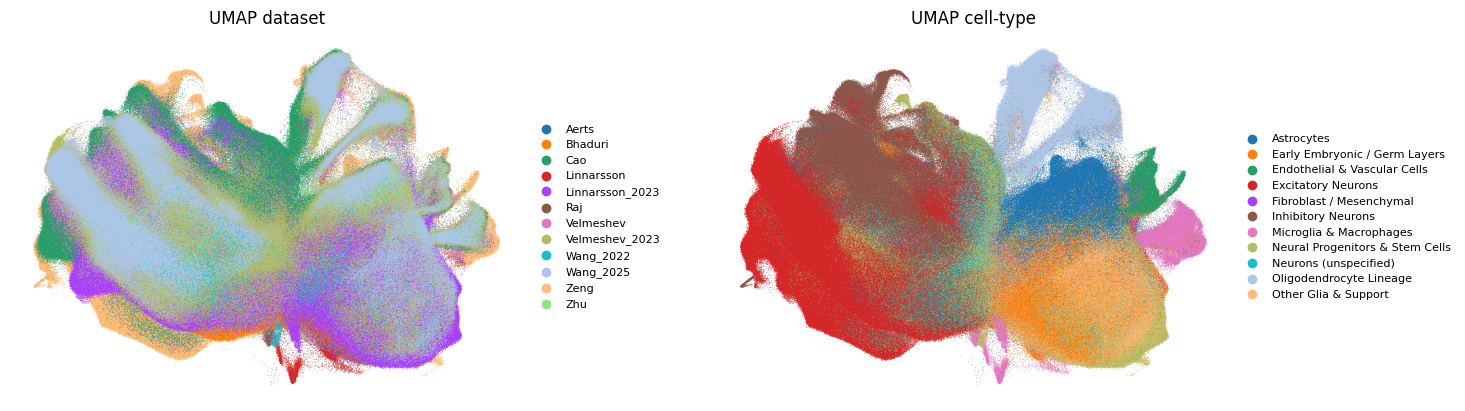

In [32]:
sc.pl.umap(
    merged_adata2,
    color=['dataset', 'supercategories'],
    wspace=0.25,
    ncols=2,
    frameon=False,
    legend_loc="right margin",     # or "right margin" for dense plots
    legend_fontsize=8,
    size=1.0,                 # tune for your cell count
    title=[f"UMAP dataset", f"UMAP cell-type"],
    use_raw=False,
    show=True
)

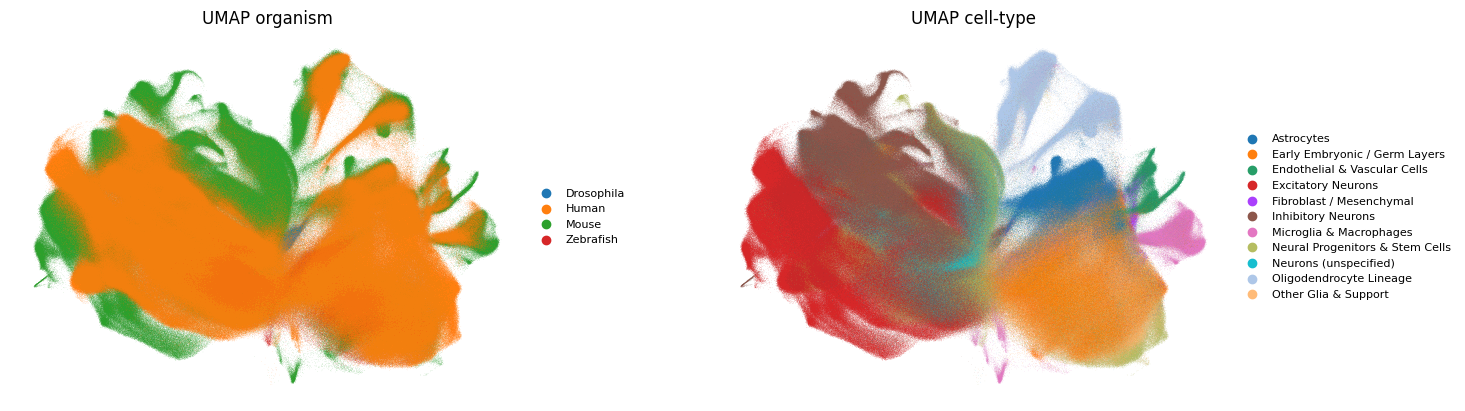

In [34]:
sc.pl.umap(
    merged_adata2,
    color=['organism', 'supercategories'],
    wspace=0.25,
    ncols=3,
    frameon=False,
    legend_loc="right margin",     # or "right margin" for dense plots
    legend_fontsize=8,
    size=0.2,                 # tune for your cell count
    title=[f"UMAP organism", f"UMAP cell-type"],
    use_raw=False,
    show=True
)

In [3]:
import pandas as pd

# Path to your CSV file
file_path = "/sc/arion/projects/ad-omics/raphael/SFARI/SFARI_genes/SFARI-Gene_genes_07-08-2025release_10-08-2025export.csv"

# Read the CSV into a DataFrame
sfari_genes = pd.read_csv(file_path)

# Inspect the first few rows
print(sfari_genes.head())

   status gene-symbol                                          gene-name  \
0       9        ABAT                   4-aminobutyrate aminotransferase   
1       9      ABCA10  ATP-binding cassette, sub-family A (ABC1), mem...   
2       9      ABCA13         ATP binding cassette subfamily A member 13   
3       9       ABCA2          ATP binding cassette subfamily A member 2   
4       9       ABCA7  ATP-binding cassette, sub-family A (ABC1), mem...   

        ensembl-id chromosome                                genetic-category  \
0  ENSG00000183044         16  Rare Single Gene Mutation, Genetic Association   
1  ENSG00000154263         17                       Rare Single Gene Mutation   
2  ENSG00000179869          7           Rare Single Gene Mutation, Functional   
3  ENSG00000107331          9                       Rare Single Gene Mutation   
4  ENSG00000064687         19                       Rare Single Gene Mutation   

   gene-score  syndromic  eagle  number-of-reports  
0  

In [13]:
sfari_syndromic = sfari_genes[sfari_genes['syndromic'] == 1].copy()

print(f"Syndromic SFARI genes: {sfari_syndromic.shape[0]}")
sfari_syndromic.head()

Syndromic SFARI genes: 309


,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
10,9,ACTB,actin beta,ENSG00000075624,7,"Rare Single Gene Mutation, Syndromic",1.0,1,1.0,11
11,9,ACTL6B,actin like 6B,ENSG00000077080,7,"Rare Single Gene Mutation, Syndromic, Functional",NaN,1,NaN,16
13,9,ACY1,aminoacylase 1,ENSG00000243989,3,"Rare Single Gene Mutation, Syndromic",NaN,1,NaN,13
19,9,ADGRL1,adhesion G protein-coupled receptor L1,ENSG00000072071,19,"Rare Single Gene Mutation, Syndromic",3.0,1,NaN,5
21,9,ADNP,Activity-dependent neuroprotector homeobox,ENSG00000101126,20,"Rare Single Gene Mutation, Syndromic, Functional",1.0,1,41.5,95


In [16]:
sfari_gs = sfari_genes[sfari_genes['gene-score'] == 1].copy()

print(f"Gene-score = 2 SFARI genes: {sfari_gs.shape[0]}")
sfari_gs.head()


Gene-score = 2 SFARI genes: 240


,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
5,9,ABCE1,ATP binding cassette subfamily E member 1,ENSG00000164163,4,Rare Single Gene Mutation,1.0,0,1.40,3
10,9,ACTB,actin beta,ENSG00000075624,7,"Rare Single Gene Mutation, Syndromic",1.0,1,1.00,11
21,9,ADNP,Activity-dependent neuroprotector homeobox,ENSG00000101126,20,"Rare Single Gene Mutation, Syndromic, Functional",1.0,1,41.50,95
23,9,ADSL,adenylosuccinate lyase,ENSG00000239900,22,"Rare Single Gene Mutation, Syndromic",1.0,1,0.35,9
25,9,AFF2,"AF4/FMR2 family, member 2",ENSG00000155966,X,"Rare Single Gene Mutation, Syndromic",1.0,0,8.70,22


In [15]:
sfari_gs = sfari_genes[sfari_genes['gene-score'] == 2].copy()

print(f"Gene-score = 2 SFARI genes: {sfari_gs.shape[0]}")
sfari_gs.head()


Gene-score = 2 SFARI genes: 706


,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
0,9,ABAT,4-aminobutyrate aminotransferase,ENSG00000183044,16,"Rare Single Gene Mutation, Genetic Association",2.0,0,NaN,8
1,9,ABCA10,"ATP-binding cassette, sub-family A (ABC1), mem...",ENSG00000154263,17,Rare Single Gene Mutation,2.0,0,NaN,4
2,9,ABCA13,ATP binding cassette subfamily A member 13,ENSG00000179869,7,"Rare Single Gene Mutation, Functional",2.0,0,NaN,14
4,9,ABCA7,"ATP-binding cassette, sub-family A (ABC1), mem...",ENSG00000064687,19,Rare Single Gene Mutation,2.0,0,NaN,6
7,9,ACAP2,"ArfGAP with coiled-coil, ankyrin repeat and PH...",ENSG00000114331,3,"Rare Single Gene Mutation, Functional",2.0,0,NaN,5


In [7]:
import pandas as pd

# Assuming you already loaded your SFARI genes
sfari_gene_symbols = sfari_genes['gene-symbol'].astype(str)

# Find overlap
overlap_genes = set(merged_adata2.var_names).intersection(sfari_gene_symbols)
print(f"Number of overlapping genes: {len(overlap_genes)}")

Number of overlapping genes: 231


In [8]:
# Subset the SFARI dataframe to only include overlapping genes
sfari_genes_overlap = sfari_genes[
    sfari_genes['gene-symbol'].str.upper().isin(overlap_genes)
].copy()

# Check result
print(f"Subsetted SFARI genes: {sfari_genes_overlap.shape[0]} rows")
sfari_genes_overlap.head()

Subsetted SFARI genes: 231 rows


,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
0,9,ABAT,4-aminobutyrate aminotransferase,ENSG00000183044,16,"Rare Single Gene Mutation, Genetic Association",2.0,0,NaN,8
5,9,ABCE1,ATP binding cassette subfamily E member 1,ENSG00000164163,4,Rare Single Gene Mutation,1.0,0,1.4,3
13,9,ACY1,aminoacylase 1,ENSG00000243989,3,"Rare Single Gene Mutation, Syndromic",NaN,1,NaN,13
16,9,ADCY3,adenylate cyclase 3,ENSG00000138031,2,Rare Single Gene Mutation,2.0,0,NaN,4
17,9,ADCY5,Adenylate cyclase 5,ENSG00000173175,3,Rare Single Gene Mutation,2.0,0,NaN,13


In [9]:
sfari_syndromic = sfari_genes_overlap[sfari_genes_overlap['syndromic'] == 1].copy()

print(f"Syndromic overlap genes: {sfari_syndromic.shape[0]}")
sfari_syndromic.head()


Syndromic overlap genes: 59


,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
13,9,ACY1,aminoacylase 1,ENSG00000243989,3,"Rare Single Gene Mutation, Syndromic",NaN,1,NaN,13
32,9,AGO2,argonaute RISC catalytic component 2,ENSG00000123908,8,"Rare Single Gene Mutation, Syndromic",2.0,1,NaN,4
42,9,ALDH5A1,"aldehyde dehydrogenase 5 family, member A1 (su...",ENSG00000112294,6,"Rare Single Gene Mutation, Syndromic, Functional",1.0,1,2.35,19
43,9,ALG6,"ALG6, alpha-1,3-glucosyltransferase",ENSG00000088035,1,"Rare Single Gene Mutation, Syndromic",NaN,1,NaN,2
69,9,ARID1A,AT-rich interaction domain 1A,ENSG00000117713,1,"Rare Single Gene Mutation, Syndromic, Functional",3.0,1,NaN,9


In [10]:
sfari_syndromic = sfari_genes_overlap[sfari_genes_overlap['gene-score'] == 2].copy()

print(f"Gene-score = 2 overlap genes: {sfari_syndromic.shape[0]}")
sfari_syndromic.head()


Syndromic overlap genes: 121


,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
0,9,ABAT,4-aminobutyrate aminotransferase,ENSG00000183044,16,"Rare Single Gene Mutation, Genetic Association",2.0,0,NaN,8
16,9,ADCY3,adenylate cyclase 3,ENSG00000138031,2,Rare Single Gene Mutation,2.0,0,NaN,4
17,9,ADCY5,Adenylate cyclase 5,ENSG00000173175,3,Rare Single Gene Mutation,2.0,0,NaN,13
20,9,ADK,adenosine kinase,ENSG00000156110,10,Rare Single Gene Mutation,2.0,0,NaN,2
29,9,AGBL4,ATP/GTP binding protein-like 4,ENSG00000186094,1,Rare Single Gene Mutation,2.0,0,NaN,5


In [11]:
sfari_syndromic = sfari_genes_overlap[sfari_genes_overlap['gene-score'] == 1].copy()

print(f"Gene-score = 1 overlap genes: {sfari_syndromic.shape[0]}")
sfari_syndromic.head()


Syndromic overlap genes: 57


,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
5,9,ABCE1,ATP binding cassette subfamily E member 1,ENSG00000164163,4,Rare Single Gene Mutation,1.0,0,1.40,3
42,9,ALDH5A1,"aldehyde dehydrogenase 5 family, member A1 (su...",ENSG00000112294,6,"Rare Single Gene Mutation, Syndromic, Functional",1.0,1,2.35,19
55,9,AP2S1,adaptor related protein complex 2 subunit sigma 1,ENSG00000042753,19,"Rare Single Gene Mutation, Functional",1.0,0,0.20,5
77,9,ASH1L,"Ash1 (absent, small, or homeotic)-like (Drosop...",ENSG00000116539,1,"Rare Single Gene Mutation, Syndromic, Genetic ...",1.0,0,14.15,42
88,9,ATRX,alpha thalassemia/mental retardation syndrome ...,ENSG00000085224,X,"Rare Single Gene Mutation, Syndromic, Functional",1.0,0,9.25,36


In [52]:
import os
import sys
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
import pyarrow as pa
import pyarrow.parquet as pq

# ========= USER CONFIG (stage-free) =========
OUT_DIR = "/sc/arion/projects/ad-omics/raphael/sfari.explorer/inst/app/data"  # where the parquet files go
ANNDATA_FILES = [
    '/sc/arion/projects/ad-omics/raphael/SFARI/data/10022025_all_adata_combined_pegasus_pca_umap_annotated_scvi.h5ad'
]

# Column names in .obs
SPECIES_COL   = "organism"
DATASET_COL   = "dataset"        # will be written as 'tissue' in outputs
CELLTYPE_COL  = "supercategories"

# Which matrix to summarize
# - None -> use .X
# - or name of a layer, e.g. "log1p_cpm" or "normalized"
LAYER = None

# Gene native symbol source (one of: var_names, var['gene_symbol'], var['mgi_symbol'], etc.)
GENE_NATIVE_FROM = "var_names"

# Gene mapping CSV (mouse→human, etc.). Expect columns: ["species","gene_native","gene_human"]
GENE_MAP_CSV = None  # set to None to skip and use identity mapping
GENE_MAP_NATIVE_COL = "gene_native"
GENE_MAP_HUMAN_COL  = "gene_human"
GENE_MAP_SPECIES_COL = "species"  # optional

# Risk genes (optional). If CSV given, it will be written as-is.
RISK_GENES_CSV = "/sc/arion/projects/ad-omics/raphael/SFARI/SFARI_genes/SFARI-Gene_genes_07-08-2025release_10-08-2025export.csv"
RISK_GENES_INLINE = []

# Partitioning: write one big Parquet file (simple) or a partitioned dataset (fast filtering)
WRITE_PARTITIONED = False   # if True, creates a dataset dir partitioned by species/tissue
# ========= END CONFIG =========


def ensure_dir(p):
    os.makedirs(p, exist_ok=True)


def get_matrix(adata: ad.AnnData, layer: str | None):
    X = adata.layers[layer] if (layer is not None and layer in adata.layers) else adata.X
    if sparse.issparse(X):
        return X.tocsr()  # fast row slicing & >0 ops
    return np.asarray(X)


def native_gene_series(adata: ad.AnnData) -> pd.Series:
    if GENE_NATIVE_FROM == "var_names":
        return pd.Series(adata.var_names, index=adata.var_names, name="gene_native")
    if GENE_NATIVE_FROM in adata.var.columns:
        s = adata.var[GENE_NATIVE_FROM].astype(str)
        s.index = adata.var_names
        s.name = "gene_native"
        return s
    raise ValueError(f"GENE_NATIVE_FROM='{GENE_NATIVE_FROM}' not found in .var")


def compute_group_stats(X, idx_rows):
    """Return mean and pct>0 for the row-subset idx_rows without densifying."""
    if sparse.issparse(X):
        sub = X[idx_rows]
        mean_expr = np.asarray(sub.mean(axis=0)).ravel()
        pct_expr  = np.asarray((sub > 0).mean(axis=0)).ravel()
        n_cells   = sub.shape[0]
    else:
        sub = X[idx_rows, :]
        n_cells = sub.shape[0]
        mean_expr = sub.mean(axis=0)
        pct_expr  = (sub > 0).mean(axis=0)
    return mean_expr, pct_expr, int(n_cells)


def summarize_one_adata(h5ad_path: str):
    print(f"-> Reading {h5ad_path}")
    adata = ad.read_h5ad(h5ad_path, backed=None)
    adata.var_names_make_unique()

    for col in [SPECIES_COL, DATASET_COL, CELLTYPE_COL]:
        if col not in adata.obs.columns:
            raise ValueError(f"Missing obs column '{col}' in {h5ad_path}")

    species_values = adata.obs[SPECIES_COL].astype(str)
    species_value = species_values.iloc[0] if species_values.nunique() == 1 else None

    X = get_matrix(adata, LAYER)
    gene_native = native_gene_series(adata)
    gene_native_arr = gene_native.reindex(adata.var_names).astype(str).values

    rows = []
    meta_rows = []

    # Group by species × dataset × cell_type
    gcols = [SPECIES_COL, DATASET_COL, CELLTYPE_COL]
    obs_small = adata.obs[gcols].astype(str).copy()
    obs_small["_row"] = np.arange(adata.n_obs, dtype=int)
    
    for (sp, ds, ctype), sub in obs_small.groupby(gcols, sort=False):
        idx = sub["_row"].to_numpy()
        mean_expr, pct_expr, n_cells = compute_group_stats(X, idx)
    
        df = pd.DataFrame({
            "species": sp,
            "tissue": ds,
            "cell_type": ctype,
            "gene_native": gene_native_arr,
            "mean_expr": mean_expr.astype(np.float32),
            "pct_expressing": pct_expr.astype(np.float32),
            "n_cells": int(n_cells),
        })
        rows.append(df)
        meta_rows.append({"species": sp, "tissue": ds, "cell_type": ctype})

    expr_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    cellmeta_df = (pd.DataFrame(meta_rows).drop_duplicates()
                   if meta_rows else pd.DataFrame(columns=["species","tissue","cell_type"]))

    # Map gene_native -> gene_human (if mapping provided)
    if GENE_MAP_CSV and os.path.exists(GENE_MAP_CSV):
        gmap = pd.read_csv(GENE_MAP_CSV)
        need_cols = {GENE_MAP_NATIVE_COL, GENE_MAP_HUMAN_COL}
        if not need_cols.issubset(gmap.columns):
            raise ValueError(f"Gene map CSV must have columns {need_cols}")
        if GENE_MAP_SPECIES_COL in gmap.columns:
            expr_df = expr_df.merge(
                gmap[[GENE_MAP_SPECIES_COL, GENE_MAP_NATIVE_COL, GENE_MAP_HUMAN_COL]].rename(
                    columns={
                        GENE_MAP_SPECIES_COL:"species",
                        GENE_MAP_NATIVE_COL:"gene_native",
                        GENE_MAP_HUMAN_COL:"gene_human"
                    }
                ),
                on=["species","gene_native"], how="left"
            )
        else:
            expr_df = expr_df.merge(
                gmap[[GENE_MAP_NATIVE_COL, GENE_MAP_HUMAN_COL]].rename(
                    columns={GENE_MAP_NATIVE_COL:"gene_native", GENE_MAP_HUMAN_COL:"gene_human"}
                ),
                on="gene_native", how="left"
            )
        mask_human = expr_df["species"].str.lower().eq("human")
        expr_df.loc[mask_human & expr_df["gene_human"].isna(), "gene_human"] = expr_df.loc[mask_human, "gene_native"]
    else:
        expr_df["gene_human"] = expr_df["gene_native"]

    # Build per-file gene_map (identity if no CSV)
    # Build gene_map directly from expr_df (handles species correctly)
    file_gene_map = (
        expr_df[["species", "gene_native", "gene_human"]]
        .drop_duplicates()
        .sort_values(["species", "gene_native"])
    )

    return expr_df, cellmeta_df, file_gene_map


def write_parquet_single(df: pd.DataFrame, path: str):
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_table(table, path)


def write_parquet_partitioned(df: pd.DataFrame, base_dir: str, partition_cols=("species","tissue"), fname="data.parquet"):
    ds_dir = os.path.join(base_dir, "dataset")
    os.makedirs(ds_dir, exist_ok=True)
    pq.write_to_dataset(pa.Table.from_pandas(df, preserve_index=False),
                        root_path=ds_dir,
                        partition_cols=list(partition_cols),
                        basename_template=fname)


def main():
    ensure_dir(OUT_DIR)

    all_expr, all_cellmeta, all_genemap = [], [], []

    for f in ANNDATA_FILES:
        expr_df, cellmeta_df, genemap_df = summarize_one_adata(f)
        all_expr.append(expr_df)
        all_cellmeta.append(cellmeta_df)
        all_genemap.append(genemap_df)

    expr_all = pd.concat(all_expr, ignore_index=True) if all_expr else pd.DataFrame()
    cellmeta_all = (pd.concat(all_cellmeta, ignore_index=True)
                      .drop_duplicates()
                      .sort_values(["species","tissue","cell_type"]))
    genemap_all = (pd.concat(all_genemap, ignore_index=True)
                     .drop_duplicates()
                     .sort_values(["species","gene_native"]))

    # Write expression_summaries
    if WRITE_PARTITIONED:
        write_parquet_partitioned(expr_all, os.path.join(OUT_DIR, "expression_summaries"),
                                  partition_cols=("species","tissue"), fname="part.parquet")
    else:
        write_parquet_single(expr_all, os.path.join(OUT_DIR, "expression_summaries.parquet"))

    # Write gene_map & celltype_meta
    write_parquet_single(genemap_all,  os.path.join(OUT_DIR, "gene_map.parquet"))
    write_parquet_single(cellmeta_all, os.path.join(OUT_DIR, "celltype_meta.parquet"))

    # Risk genes
    if RISK_GENES_CSV and os.path.exists(RISK_GENES_CSV):
        risk_df = pd.read_csv(RISK_GENES_CSV)
    else:
        risk_df = pd.DataFrame(RISK_GENES_INLINE) if RISK_GENES_INLINE else pd.DataFrame(
            columns=["gene_human","panel_name","source","notes"]
        )
    write_parquet_single(risk_df, os.path.join(OUT_DIR, "risk_genes.parquet"))

    print("Wrote:")
    if WRITE_PARTITIONED:
        print(f"  - {os.path.join(OUT_DIR, 'expression_summaries/dataset/')}/ (partitioned dataset)")
    else:
        print(f"  - {os.path.join(OUT_DIR, 'expression_summaries.parquet')}")
    print(f"  - {os.path.join(OUT_DIR, 'gene_map.parquet')}")
    print(f"  - {os.path.join(OUT_DIR, 'celltype_meta.parquet')}")
    print(f"  - {os.path.join(OUT_DIR, 'risk_genes.parquet')}")
    return 0


main()

-> Reading /sc/arion/projects/ad-omics/raphael/SFARI/data/10022025_all_adata_combined_pegasus_pca_umap_annotated_scvi.h5ad
Wrote:
  - /sc/arion/projects/ad-omics/raphael/sfari.explorer/expression_summaries.parquet
  - /sc/arion/projects/ad-omics/raphael/sfari.explorer/gene_map.parquet
  - /sc/arion/projects/ad-omics/raphael/sfari.explorer/celltype_meta.parquet
  - /sc/arion/projects/ad-omics/raphael/sfari.explorer/risk_genes.parquet


SystemExit: 0

/sc/arion/projects/ad-omics/raphael/conda/envs/scvi_cellassign/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
